# Experimental Setup and LFPs

### Setup: Parameters, Time Windows, Mappings, and Paths

In [1]:
import numpy as np

BUFFER_BEFORE_SEC = 0.5  # Spont
BUFFER_AFTER_SEC = 2.5 + 1.4  # Sound-Break

time_windows_dict = {
    'Spontaneous': (-np.inf, -0.1), 
    'Sound': (0, 2.5), 
    'Persistence': (2.5, BUFFER_AFTER_SEC), 
}

colors = {
    'wake': 'deeppink',
    'sleep': '#2E8B57',
    'high': 'deeppink',
    'low': '#4682B4'
}

name_mapping = {"low": 'early', 'high': 'late'}

MAIN_PATH = r'input_path'  ## Path to where the raw data is saved (raw data is not available due to size)
DATA_PATH = MAIN_PATH + rf"\Submission"  ## Path to where the processed data is saved (after we ran PROCESS_RAW=True)

# Flag to control raw-data processing.
# Processing raw LFP/timeseries is computationally heavy: one 4-hour session ~26 GB of LFP data.
# Set to True only if you have the raw files available and enough memory/disk/time.
PROCESS_RAW = False

### Subject-Specific Configuration: Dates, Channel Ranges, and Max Recording Time

In [2]:
subjects_data = {
    'C9': {
        'folders_dates_to_collect': ['20240312', '20240317', '20240319'],
        'MAX_HOUR_IN_SECONDS': 60*60*2,
        'high_ch': [0, 100],
        'low_ch': [100, 200]
    },
    'C11': {
        'folders_dates_to_collect': ['20240911', '20240917'],
        'MAX_HOUR_IN_SECONDS': 60*60*4,
        'high_ch': [50, 150],
        'low_ch': [150, 250]
    },
    'C12': {
        'folders_dates_to_collect': ['20241007', '20241008'],
        'MAX_HOUR_IN_SECONDS': 60*60*4,
        'high_ch': [90, 190],
        'low_ch': [190, 290]
    },
    'C14': {
        'folders_dates_to_collect': ['20241112', '20241113'],
        'MAX_HOUR_IN_SECONDS': 60*60*4,
        'high_ch': [100, 200],
        'low_ch': [200, 300]
    },
    'C16': {
        'folders_dates_to_collect': ['20250211', '20250212'],
        'MAX_HOUR_IN_SECONDS': 60*60*4,
        'high_ch': [150, 250],
        'low_ch': [250, 350]
    }
}

### Select Example Subject and Session for LFP Plotting

In [3]:
subject_id = 'C11'
cur_date = subjects_data[subject_id]['folders_dates_to_collect'][0]
MAX_HOUR_IN_SECONDS = subjects_data[subject_id]['MAX_HOUR_IN_SECONDS']
SoundType = 101
save_path_LFP = DATA_PATH + rf"\{subject_id}_{cur_date}_LFPs_dict.pkl"
save_path_hypno = DATA_PATH + rf"\{subject_id}_{cur_date}_hypnogram.pkl"

### Dependencies and Core Functions (Loading, Filtering, Analysis)

In [4]:
import os
import re
import scipy
import numpy as np
from Analysis_pipeline.Global_functions import read_file_by_time_steps
from pathlib import Path
import pickle
import scipy.io
from scipy.signal import spectrogram
from scipy.signal import butter, filtfilt
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter
from mne.time_frequency import tfr_array_morlet
from mne.stats import permutation_cluster_1samp_test
import tqdm

def extract_latency_amplitude(LFPs_sleep, LFPs_wake, t_LFP,
                              n_permutations=1000,
                              alpha=0.05,
                              tail=0):
    """
    Extract latency and amplitude per channel for sleep and wake
    using cluster-based permutation test against baseline.

    Parameters
    ----------
    n_permutations : int
        Number of permutations for cluster test.
    alpha : float
        Significance level for clusters.
    tail : int
        Tail of the test: 0 (two-sided), 1 (positive), -1 (negative).

    Returns
    -------
    results : dict
        {"sleep": {"amp","lat","ch"},
         "wake": {"amp","lat","ch"}}
    """
    trials_sleep = np.swapaxes(LFPs_sleep, 0, 1)  # (n_ch, n_trials, n_times)
    trials_wake  = np.swapaxes(LFPs_wake, 0, 1)
    print(trials_sleep.shape, trials_wake.shape)
    t_LFP = t_LFP

    # Define baseline and post-stim masks
    baseline_mask = t_LFP < 0
    post_mask = (t_LFP >= 0) & (t_LFP < 0.08)

    def analyze_state(trials):
        latencies = []
        amplitudes = []
        keep_mask = []
        
        for ch in tqdm.tqdm(range(trials.shape[0])):
            X = trials[ch]  # shape (n_trials, n_times)
            # baseline correction
            baseline = X[:, baseline_mask].mean(axis=1, keepdims=True)
            X = X - baseline

            # restrict to post window
            X_post = X[:, post_mask]

            # run cluster test
            T_obs, clusters, cluster_pv, _ = permutation_cluster_1samp_test(
                X_post, n_permutations=n_permutations, tail=tail, out_type='mask', verbose=False
            )

            # find significant clusters
            sig_clusters = [cl for cl, p in zip(clusters, cluster_pv) if p < alpha]

            if not sig_clusters:
                latencies.append(np.nan)
                amplitudes.append(np.nan)
                keep_mask.append(False)
                continue
            
            onset_time = np.inf
            for cl in sig_clusters:
                # find time of maximum absolute T-value within cluster
                cluster_idx = np.arange(X_post.shape[1])[cl[0]]
                peak_idx = cluster_idx[np.argmax(np.abs(T_obs[cluster_idx]))]
                cur_onset_time = t_LFP[post_mask][peak_idx]
                if cur_onset_time < onset_time:
                    onset_time = cur_onset_time
                
            # earliest significant cluster onset
            # earliest_cluster = min([np.where(cl)[0][0] for cl in sig_clusters])
            # onset_time = t_LFP[post_mask][earliest_cluster]

            # amplitude at that latency
            onset_idx = np.argmin(np.abs(t_LFP - onset_time))
            amp = X[:, onset_idx].mean(axis=0)
            
            # print(ch, amp, onset_time)
            latencies.append(onset_time)
            amplitudes.append(amp)
            keep_mask.append(True)

        channels = np.arange(trials.shape[0])
        return {
            "amp": np.array(amplitudes),
            "lat": np.array(latencies),
            "ch":  channels,
        }

    results = {
        "sleep": analyze_state(trials_sleep),
        "wake":  analyze_state(trials_wake)
    }
    return results


def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)

def find_files(root_folder, pattern):
    # Compile the regex pattern for matching
    regex = re.compile(pattern)
    
    matching_files = []
    for dirpath, dirnames, filenames in os.walk(root_folder):
        for filename in filenames:
            if regex.match(filename):
                file_path = os.path.join(dirpath, filename)
                matching_files.append(file_path)
                # print(f"File found: {file_path}")
    return matching_files

def load_hypnogram(SleepWakeEEG_path, SleepWakeEMG_path, SleepWakeLabels_path, MAX_HOUR_IN_SECONDS):
    """ Load Hypnogram Data and Compute Spectrogram """
    # Load labels
    SleepWakeLabels = scipy.io.loadmat(SleepWakeLabels_path)
    labels = np.squeeze(SleepWakeLabels['labels'])
    SleepWakeTimes = np.linspace(0, MAX_HOUR_IN_SECONDS, len(labels))  # the stop value is set by the time I used for manual scoring

    # Load EEG and EMG
    EEG = scipy.io.loadmat(SleepWakeEEG_path)
    EEG = np.squeeze(EEG['EEG'])

    EMG = scipy.io.loadmat(SleepWakeEMG_path)
    EMG = np.squeeze(EMG['EMG'])

    sampling_rate = int(EEG.shape[0] / MAX_HOUR_IN_SECONDS)
    
    # Filter EEG before spectrogram
    EEG = bandpass_filter(EEG, 0.5, 50.0, sampling_rate)

    # Compute EEG spectrogram
    freqs_spec, times_spec, Sxx = spectrogram(
        EEG, 
        fs=sampling_rate, 
        nperseg=int(25 * sampling_rate), 
        noverlap=int(23 * sampling_rate),
        scaling='density'
    )
    # Log power (add small epsilon to avoid log(0))
    Sxx_log = 10 * np.log10(Sxx + 1e-10)
    
    from scipy.ndimage import gaussian_filter
    Sxx_log = gaussian_filter(Sxx_log, sigma=(6, 1.5))


    return {
        'labels': labels,
        'labels_times': SleepWakeTimes,
        'EEG': EEG,
        'EMG': EMG,
        'Sxx_log': Sxx_log,
        'freqs_spec': freqs_spec,
        'times_spec': times_spec,
        'sr': sampling_rate
    }


def load_paths_LFP(cur_date):
    """ Find All Required Raw Data File Paths """
    main_folder = [folder for folder in os.listdir(MAIN_PATH) if os.path.isdir(os.path.join(MAIN_PATH, folder)) and folder.startswith(f'{cur_date}')][0]
    
    main_folder = os.path.join(MAIN_PATH, main_folder)
    
    SleepWakeLabels_fname = 'labels_All.mat'
    SleepWakeEEG_fname = 'EEG.mat'
    SleepWakeEMG_fname = 'EMG.mat'

    TTL_times_fname = 'TTL_times_adj.txt'
    TTL_labels_fname = 'TTL_labels.txt'
    LFP_path_fname = r'.*\.lf\.bin$'
    
    LFP_path = find_files(main_folder, LFP_path_fname)[0]
    TTL_labels_path = find_files(main_folder, TTL_labels_fname)[0]
    TTL_times_path = find_files(main_folder, TTL_times_fname)[0]
    SleepWakeLabels_path = find_files(main_folder, SleepWakeLabels_fname)[0]
    try:
        SleepWakeEEG_path = find_files(main_folder, SleepWakeEEG_fname)[0]
    except:
        SleepWakeEEG_path = None
    try:
        SleepWakeEMG_path = find_files(main_folder, SleepWakeEMG_fname)[0]
    except:
        SleepWakeEMG_path = None

    return LFP_path, TTL_labels_path, TTL_times_path, SleepWakeLabels_path, SleepWakeEEG_path, SleepWakeEMG_path

def load_data(LFP_path, TTL_labels_path, TTL_times_path, SleepWakeLabels_path, MAX_HOUR_IN_SECONDS, N_trials_read, SoundType):
    """ Load LFP Trials, Baseline Correct, and Run Latency Analysis """
    TTL_times = np.loadtxt(TTL_times_path)
    TTL_labels = np.loadtxt(TTL_labels_path).astype(int)
    
    SleepWakeLabels =  scipy.io.loadmat(SleepWakeLabels_path)
    SleepWakeLabels = np.squeeze(SleepWakeLabels['labels'])
    SleepWakeTimes = np.linspace(0, MAX_HOUR_IN_SECONDS, len(SleepWakeLabels))  # the stop value is set by the time I used for manual scoring
    
    LFPs_dict = {} # Dictionary sound -> State -> (n_trials, n_channels, n_time_bins)
    
    if SoundType == 100:
        TTL_picked = (TTL_labels > 100) & (TTL_labels < 200)
    elif SoundType == 400:
        TTL_picked = (TTL_labels > 400) & (TTL_labels < 600)
    elif SoundType == 1300:
        TTL_picked = (TTL_labels > 1300) & (TTL_labels < 1400)
    elif SoundType == 1400:
        TTL_picked = (TTL_labels > 1400) & (TTL_labels < 1500)
    else:
        TTL_picked = (TTL_labels == SoundType)
    
    
    print(f'SoundType {SoundType} - Number of trials: {np.sum(TTL_picked)}')
    
    cur_SoundType_trialsTimes = TTL_times[TTL_picked]
    cur_SoundType_trialsTimes = cur_SoundType_trialsTimes[cur_SoundType_trialsTimes > 1]
            
    closest_SleepWakeTimes = []
    for curTTLtime in cur_SoundType_trialsTimes:
        closest_SleepWakeTimes.append(np.argmin(np.abs(SleepWakeTimes - curTTLtime)))
    
    cur_SoundType_SleepWakeLabels = SleepWakeLabels[closest_SleepWakeTimes]
    
    All_TrialsTimes = cur_SoundType_trialsTimes
    Sleep_TrialsTimes = cur_SoundType_trialsTimes[cur_SoundType_SleepWakeLabels == 3]
    print(f'Sleep - Number of trials: {len(Sleep_TrialsTimes)}')
    Wake_TrialsTimes = cur_SoundType_trialsTimes[cur_SoundType_SleepWakeLabels == 2]
    print(f'Wake - Number of trials: {len(Wake_TrialsTimes)}')
    
    # Get indices of Sleep and Wake trials in All_TrialsTimes
    sleep_idxs = np.where(cur_SoundType_SleepWakeLabels == 3)[0]
    wake_idxs = np.where(cur_SoundType_SleepWakeLabels == 2)[0]
            
    # Randomly pick indices
    picked_sleep_idxs = np.random.choice(sleep_idxs, N_trials_read//2, replace=False)
    picked_wake_idxs = np.random.choice(wake_idxs, N_trials_read//2, replace=False)
    picked_idxs = np.concatenate([picked_sleep_idxs, picked_wake_idxs])
    Picked_TrialsTimes = All_TrialsTimes[picked_idxs]

    # Picked_TrialsTimes = All_TrialsTimes
    Trials_read_times_start = Picked_TrialsTimes - BUFFER_BEFORE_SEC
    
    tstep = BUFFER_AFTER_SEC + BUFFER_BEFORE_SEC
    chanList = list(range(1, 384)) # List of channels to plot
    
    LFPs_by_trials, sr_LFP = read_file_by_time_steps(Path(LFP_path), Trials_read_times_start, tstep, chanList)
    min_length = min(arr.shape[1] for arr in LFPs_by_trials)
    LFPs_by_trials = [arr[:, :min_length] for arr in LFPs_by_trials]
    LFPs_by_trials = np.stack(LFPs_by_trials, axis=1)
    
    t_LFP = np.linspace(-BUFFER_BEFORE_SEC, BUFFER_AFTER_SEC, LFPs_by_trials.shape[2])
    
    ''' LFPs_by_trials (N_channels, N_trials, len_Trial) '''
    'Remove baseline per trial'
    LFPs_by_trials = LFPs_by_trials - np.expand_dims(np.mean(LFPs_by_trials[:,:,t_LFP<0], axis=2), axis=2)
    
    LFPs_by_trials = np.swapaxes(LFPs_by_trials, 0, 1)
    
    LFP_Sleep = np.squeeze(LFPs_by_trials[:N_trials_read//2, :, :])
    LFP_Wake = np.squeeze(LFPs_by_trials[N_trials_read//2:, :, :])
    
    results = extract_latency_amplitude(LFP_Sleep, LFP_Wake, t_LFP)

    # 1. Averaged trial response per condition (channel vs time)
    mean_sleep = LFP_Sleep.mean(axis=0)  # (n_channels, n_time_bins)
    mean_wake = LFP_Wake.mean(axis=0)
    
    # 2. Channel with largest peak after time 0
    post_zero = t_LFP > 0
    peak_chan_sleep = np.argmax(np.max(np.abs(mean_sleep[:, post_zero]), axis=1))
    peak_ch_sleep = LFP_Sleep[:, peak_chan_sleep, :].T
    peak_ch_wake = LFP_Wake[:, peak_chan_sleep, :].T
    
    # 3. Mean over all channels (amplitude vs. time)
    mean_over_chan_sleep = mean_sleep.mean(axis=0)
    mean_over_chan_wake = mean_wake.mean(axis=0)
    
    LFPs_dict[SoundType] = {}  # Initialize nested dict
    LFPs_dict[SoundType]['Mean_Sleep'] = mean_sleep
    LFPs_dict[SoundType]['Mean_Wake'] = mean_wake
    LFPs_dict[SoundType]['Peak_ch'] = peak_chan_sleep
    LFPs_dict[SoundType]['Trials_sleep'] = peak_ch_sleep
    LFPs_dict[SoundType]['Trials_Wake'] = peak_ch_wake
    LFPs_dict[SoundType]['Mean_Sleep_trace'] = mean_over_chan_sleep
    LFPs_dict[SoundType]['Mean_Wake_trace'] = mean_over_chan_wake
    LFPs_dict[SoundType]['t_LFP'] = t_LFP
    LFPs_dict[SoundType]['LatencyAmp'] = results
    
    del LFPs_by_trials, LFP_Wake, LFP_Sleep
    
    return LFPs_dict


if PROCESS_RAW:
    """ Data Processing Block: Load, Analyze, and Save Raw Data (Set PROCESS_RAW=True to run ; only possible if you have the raw data) """
    
    ''' Load random N_trials_read of LFP trials split equally between NREM and wake states. Save into LFPs_dict all the data needed for later figure. '''
    N_trials_read = 100
    LFP_path, TTL_labels_path, TTL_times_path, SleepWakeLabels_path, SleepWakeEEG_path, SleepWakeEMG_path = load_paths_LFP(cur_date)
    
    LFPs_dict = load_data(LFP_path, TTL_labels_path, TTL_times_path, SleepWakeLabels_path, MAX_HOUR_IN_SECONDS, N_trials_read, SoundType)

    with open(save_path_LFP, 'wb') as f:
        pickle.dump(LFPs_dict, f)
    
    ''' Create the spectrogram used for sleep scoring. Extracted from the EEG path. Load all data needed for Figure 1. '''
    hypnogram = load_hypnogram(SleepWakeEEG_path, SleepWakeEMG_path, SleepWakeLabels_path, MAX_HOUR_IN_SECONDS)
    with open(save_path_hypno, 'wb') as f:
        pickle.dump(hypnogram, f)
        
if not PROCESS_RAW: 
    """ Load Processed LFP and Hypnogram Data """
    with open(save_path_LFP, 'rb') as f:
        LFPs_dict = pickle.load(f)
        
    with open(save_path_hypno, 'rb') as f:
        hypnogram = pickle.load(f)

### Function: Plot Multi-Panel Hypnogram (Figure 1 D-G)

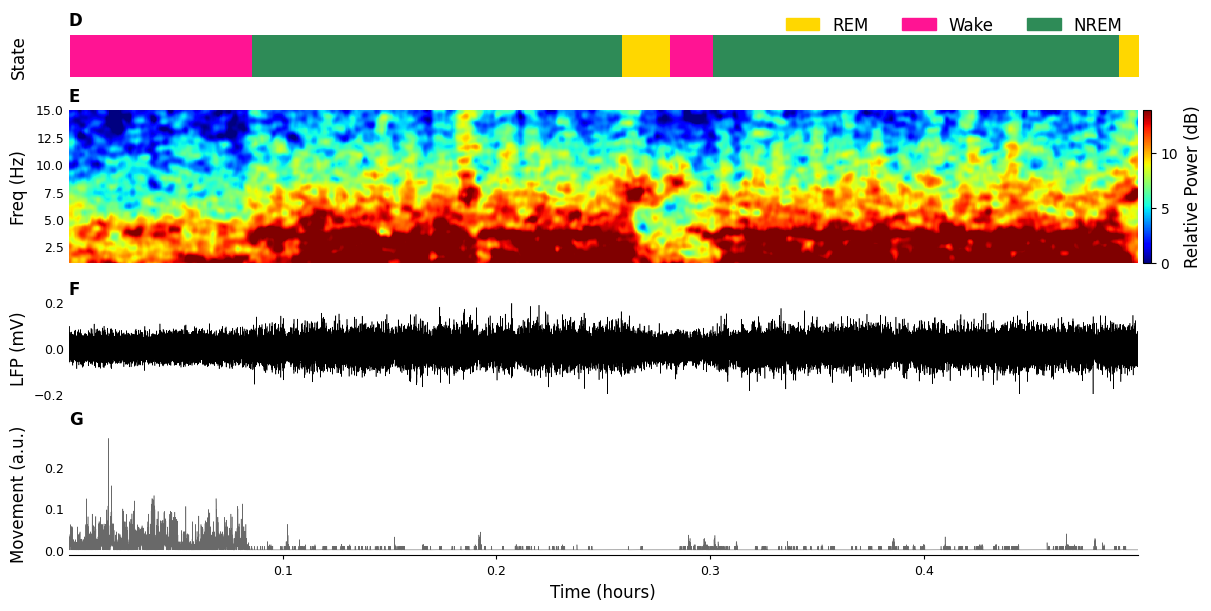

In [6]:
import matplotlib.patches as mpatches
import numpy as np
import fitz  # PyMuPDF
import matplotlib.pyplot as plt
from PIL import Image
plt.style.use('default')  # resets to pre-Seaborn/Matplotlib default

def plot_hypnogram(axs, hypno_data, time_range_sec=None):
    EEG = hypno_data['EEG']
    EMG = hypno_data['EMG']
    labels = hypno_data['labels']
    labels_times = hypno_data['labels_times']
    Sxx_log = hypno_data['Sxx_log']
    freqs_spec = hypno_data['freqs_spec']
    times_spec = hypno_data['times_spec']
    sampling_rate = hypno_data['sr']

    # Time vector
    total_time = len(EEG) / sampling_rate
    time_eeg = np.linspace(0, total_time, len(EEG))

    if time_range_sec is not None:
        t_start, t_end = time_range_sec

        idx_eeg = (time_eeg >= t_start) & (time_eeg <= t_end)
        EEG = EEG[idx_eeg]
        EMG = EMG[idx_eeg]
        time_eeg = time_eeg[idx_eeg]

        idx_spec = (times_spec >= t_start) & (times_spec <= t_end)
        Sxx_log = Sxx_log[:, idx_spec]
        times_spec = times_spec[idx_spec]

        idx_labels = (labels_times >= t_start) & (labels_times <= t_end)
        labels = labels[idx_labels]
        labels_times = labels_times[idx_labels]

    # Convert time to hours
    time_eeg_hr = time_eeg / 3600 - time_range_sec[0] / 3600 
    times_spec_hr = times_spec / 3600 - time_range_sec[0] / 3600
    labels_times_hr = labels_times / 3600 - time_range_sec[0] / 3600

    # State mapping
    label_mapping = {1: 'REM', 2: 'Wake', 3: 'NREM'}
    unique_labels = sorted(np.unique(labels))

    # Colorblind-friendly pastel colors
    # colors = {
    # 'sleep': '#CC3366',  # Darker rose (was light pink)
    # 'wake': '#2E8B57',   # Sea Green (darker than soft green)
    # 'peak': '#FF6B6B',   # Keep coral as is
    # 'high': '#FFD700',   # Gold — higher contrast than pale yellow
    # 'low': '#4682B4'     # Light Sea Green — stronger than mint
    # }
    
    pastel_palette = {
        2: 'deeppink',  # Wake - soft pink
        1: 'gold',  # REM - light blue
        3: '#2E8B57'   # N-REM - soft green
    }

    # 1. State bar (hypnogram)
    label_duration = (labels_times_hr[1] - labels_times_hr[0]) if len(labels_times_hr) > 1 else 1/3600
    for t, label in zip(labels_times_hr, labels):
        axs[0].fill_between([t, t + label_duration], 0, 1, color=pastel_palette[label], linewidth=0, rasterized=True)

    axs[0].set_yticks([])
    axs[0].set_ylabel('State', fontsize=12)
    axs[0].set_xlim(time_eeg_hr[0], time_eeg_hr[-1])
    axs[0].set_title('D', loc='left', weight='bold')
    
    # Legend
    handles = [
        mpatches.Patch(color=pastel_palette[label], label=label_mapping.get(label, f'State {label}'))
        for label in unique_labels
    ]
    axs[0].legend(handles=handles, loc='upper right', fontsize=12, frameon=False, ncol=len(handles), bbox_to_anchor=(1, 1.7))

    # 2. Spectrogram
    # Shift all values so that vmin becomes 0 dB
    vmin = np.percentile(Sxx_log, 92)
    vmax = np.percentile(Sxx_log, 99.2)
    Sxx_log_rel = Sxx_log - vmin
    vmax_rel = vmax - vmin
    
    # Plot
    im = axs[1].pcolormesh(
        times_spec_hr, freqs_spec, Sxx_log_rel, 
        shading='auto', cmap='jet',
        vmin=0, vmax=vmax_rel, rasterized=True
    )
    
    
    axs[1].set_ylabel('Freq (Hz)', fontsize=12)
    axs[1].set_xlim(times_spec_hr[0], times_spec_hr[-1])
    axs[1].set_ylim(1, 15)
    axs[1].set_title('E', loc='left', weight='bold')

    # 3. EEG trace
    axs[2].plot(time_eeg_hr, EEG, color='black', lw=0.4)
    axs[2].set_ylabel('LFP (mV)', fontsize=12)
    axs[2].set_xlim(time_eeg_hr[0], time_eeg_hr[-1])
    axs[2].set_ylim(-0.2, 0.2)
    axs[2].set_title('F', loc='left', weight='bold')

    # 4. EMG trace
    axs[3].plot(time_eeg_hr, EMG, color='dimgray', lw=0.4)
    axs[3].set_ylabel('Movement (a.u.)', fontsize=12)
    axs[3].set_xlabel('Time (hours)', fontsize=12)
    axs[3].set_xlim(time_eeg_hr[0], time_eeg_hr[-1])
    axs[3].set_title('G', loc='left', weight='bold')

    # Style all axes
    for i, ax in enumerate(axs):
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.set_anchor('N')  # Anchor top center of the axis box

        ax.tick_params(axis='both', which='both', length=0, labelsize=9)
        if i != len(axs) - 1:
            ax.set_xticks([])
        else:
            ax.spines['bottom'].set_visible(True)
            ax.tick_params(axis='x', length=3)
            

    axs[3].spines['bottom'].set_visible(True)
    fig.align_ylabels(axs)

    # plt.show()
    return fig, im

fig, axs = plt.subplots(
    4, 1, figsize=(12, 6),
    gridspec_kw={'height_ratios': [0.3, 1.0, 0.6, 0.8], 'hspace': 0.05}, constrained_layout=True
)

fig, im = plot_hypnogram(axs, hypnogram, time_range_sec=(0.6*60*60, 1.1*60*60))
cbar = fig.colorbar(im, ax=axs[1], pad=0.005)
cbar.set_label('Relative Power (dB)', fontsize=12)

### Plot and Save Figure 1 (Setup, Trajectory, and Hypnogram)

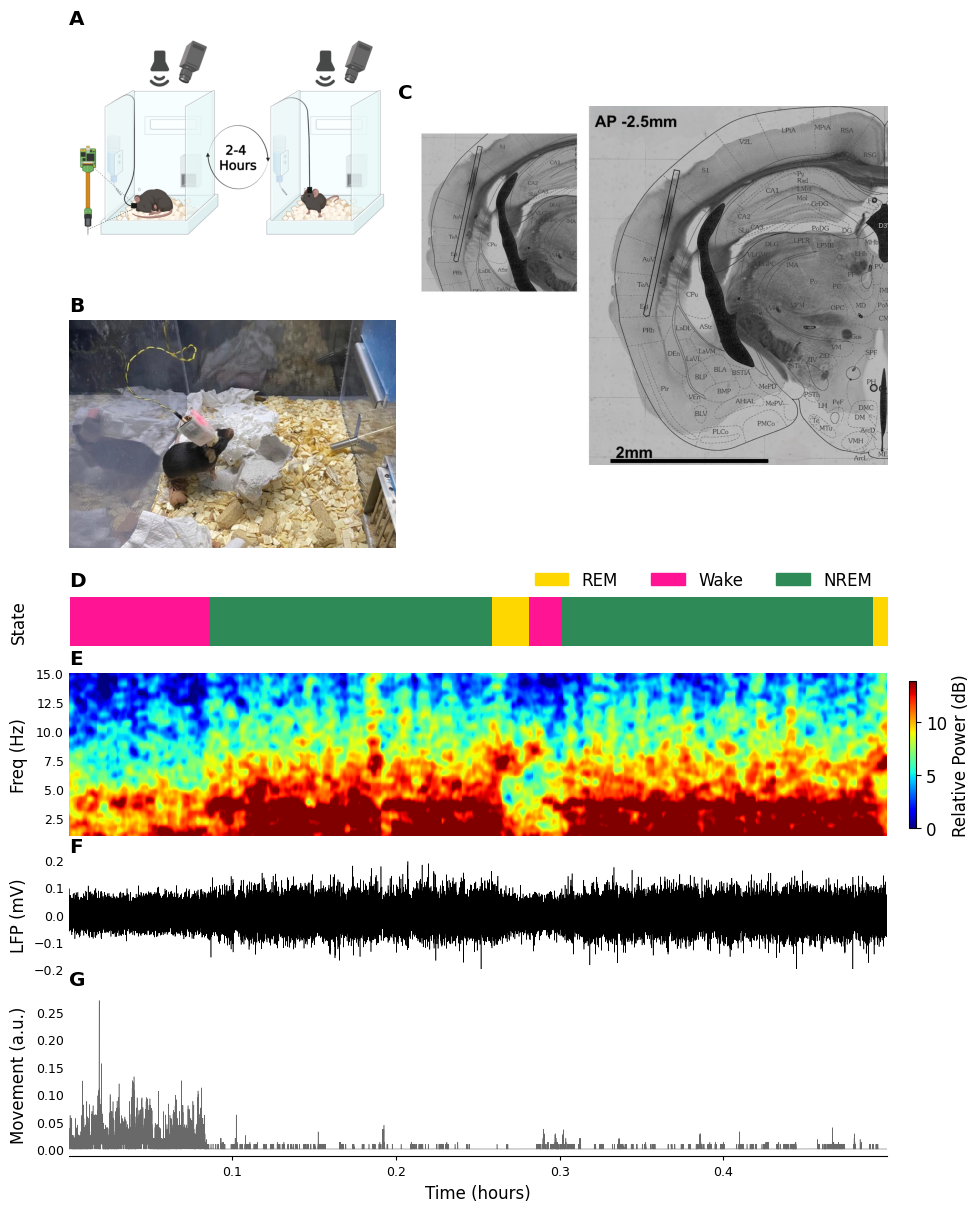

In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
from matplotlib import gridspec

# --- Load images ---
mouse_img = cv2.cvtColor(cv2.imread(DATA_PATH + r"\Mouse_with_crown.jpg"), cv2.COLOR_BGR2RGB)
setup_img = cv2.cvtColor(cv2.imread(DATA_PATH + r"\SetUp_BioRender.png"), cv2.COLOR_BGR2RGB)
histology_img = cv2.cvtColor(cv2.imread(DATA_PATH + r"\histoglogy_picture.jpg"), cv2.COLOR_BGR2RGB)

mouse_img = mouse_img[350:850, :, :]
histology_img = histology_img[:, 300:, :]

aspect_ratio = mouse_img.shape[0] / histology_img.shape[0]

fig = plt.figure(figsize=(12, 15))
plt.rcParams.update({'font.size': 12})

gs = gridspec.GridSpec(6, 3,
                       height_ratios=[0.5, 0.5, 0.1, 0.3, 0.2, 0.3],
                       width_ratios=[0.6, 0.9, 0.2],
                       hspace=0.14, wspace=0.01)

# Setup axes with spanning
ax_setup = fig.add_subplot(gs[0, 0])

ax_mouse = fig.add_subplot(gs[1, 0])

ax_hist = fig.add_subplot(gs[0:2, 1])

# Hypnogram axes: 4 rows in col 0 and 1
axs_hypno = [fig.add_subplot(gs[i, 0:2]) for i in range(2, 6)]

# Colorbar axis spanning hypnogram rows
cbar_ax = fig.add_subplot(gs[3, 1:3])
cbar_ax.axis('off')

ax_setup.imshow(setup_img)
ax_setup.set_title('A', loc='left', weight='bold')
ax_mouse.imshow(mouse_img)
ax_mouse.set_title('B', loc='left', weight='bold')
ax_hist.imshow(histology_img)
ax_hist.set_title('C', loc='left', weight='bold')

for ax in [ax_setup, ax_mouse, ax_hist]:
    ax.axis('off')
    
# Panel D–F: Hypnogram
_, im = plot_hypnogram(axs_hypno, hypnogram, time_range_sec=(0.6*60*60, 1.1*60*60))
cbar = fig.colorbar(im, ax=cbar_ax, shrink=0.9, pad=0.005)
cbar.set_label('Relative Power (dB)', fontsize=12)

fig.savefig(DATA_PATH + r"\Figure_1.pdf", dpi=300, bbox_inches='tight')
fig.savefig(DATA_PATH + r"\Figure_1.tiff", dpi=300, bbox_inches='tight')
fig.savefig(DATA_PATH + r"\Figure_1.jpg", dpi=300, bbox_inches='tight')

## Statistics for latency and amplitude
Extract the latency and amplitude for all sounds and all sessions

In [12]:
import pandas as pd

def collect_latency_amplitude_stats(subjects_data, sounds, N_trials_read=100):
    """ Collect Latency/Amplitude Stats Across All Sessions/Sounds """
    all_results = []

    for subject_id, cur_subject in subjects_data.items():
        print(f"Processing subject {subject_id}")
        high_ch = cur_subject['high_ch']
        low_ch = cur_subject['low_ch']
        time_max = cur_subject['MAX_HOUR_IN_SECONDS']

        for session_id, cur_date in enumerate(cur_subject['folders_dates_to_collect']):
            print(f"  Session {session_id} ({cur_date})")

            # Load data for this session
            LFP_path, TTL_labels_path, TTL_times_path, SleepWakeLabels_path, _, _ = load_paths_LFP(cur_date)

            for sound in sounds:
                # Load and extract
                LFPs_dict = load_data(LFP_path, TTL_labels_path, TTL_times_path,
                                      SleepWakeLabels_path, time_max, N_trials_read, sound)
                results = LFPs_dict[sound]['LatencyAmp']

                # Sleep & wake loop
                for state in ["sleep", "wake"]:
                    amps = results[state]["amp"]
                    lats = results[state]["lat"]
                    chans = results[state]["ch"]

                    # Label regions
                    for amp, lat, ch in zip(amps, lats, chans):
                        if high_ch[0] <= ch <= high_ch[1]:
                            region = "high"
                        elif low_ch[0] <= ch <= low_ch[1]:
                            region = "low"
                        else:
                            region = "other"

                        all_results.append({
                            "Subject": subject_id,
                            "Session": session_id,
                            "Date": cur_date,
                            "Sound": sound,
                            "State": state,
                            "Channel": ch,
                            "Region": region,
                            "Amplitude": amp,
                            "Latency": lat
                        })

    df_all = pd.DataFrame(all_results)
    return df_all

# Flag to control raw-data processing.
# Processing raw LFP/timeseries is computationally heavy: one 4-hour session ~26 GB of LFP data.
# Set to True only if you have the raw files available and enough memory/disk/time.
PROCESS_RAW_STAT = False
save_path_LFP_stat = DATA_PATH + r"\LFPs_stats.pkl"

if PROCESS_RAW_STAT:
    sounds = [101, 400, 1300]
    df_mega = collect_latency_amplitude_stats(subjects_data, sounds)
    with open(save_path_LFP_stat, 'wb') as f:
        pickle.dump(df_mega, f)
else:
    with open(save_path_LFP_stat, 'rb') as f:
        df_mega = pickle.load(f)

In [13]:
df_mega.head(20)

,Subject,Session,Date,Sound,State,Channel,Region,Amplitude,Latency
0,C9,0,20240312,101,sleep,0,high,NaN,NaN
1,C9,0,20240312,101,sleep,1,high,NaN,NaN
2,C9,0,20240312,101,sleep,2,high,NaN,NaN
3,C9,0,20240312,101,sleep,3,high,NaN,NaN
4,C9,0,20240312,101,sleep,4,high,NaN,NaN
5,C9,0,20240312,101,sleep,5,high,NaN,NaN
6,C9,0,20240312,101,sleep,6,high,NaN,NaN
7,C9,0,20240312,101,sleep,7,high,NaN,NaN
8,C9,0,20240312,101,sleep,8,high,NaN,NaN
9,C9,0,20240312,101,sleep,9,high,NaN,NaN


### Compute Summary Statistics (Mean Latency/Amp by State/Region)

In [14]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

''' Compute summary statistics over states and regions ''' 
def compute_summary_stats(df_mega):
    """
    Returns a dataframe with mean latency and amplitude per Subject, Date, State, Region
    averaged over channels.
    """
    # Absolute value for amplitude
    df_mega["Amplitude_abs"] = np.abs(df_mega["Amplitude"])
    
    # Group by Subject, Date, State, Region and average over channels
    df_summary = df_mega.groupby(["Subject", "Date", "State", "Region"]).agg(
        Latency_mean=("Latency", "mean"),
        Amp_mean=("Amplitude_abs", "mean")
    ).reset_index()

    # Now compute mean and std across subjects (average over dates first)
    df_final = df_summary.groupby(["Subject", "State", "Region"]).agg(
        Latency_mean_subject=("Latency_mean", "mean"),
        Amp_mean_subject=("Amp_mean", "mean")
    ).reset_index()

    # Finally, get mean and std across subjects
    stats_df = df_final.groupby(["State", "Region"]).agg(
        Latency_mean=("Latency_mean_subject", "mean"),
        Latency_std=("Latency_mean_subject", "std"),
        Amp_mean=("Amp_mean_subject", "mean"),
        Amp_std=("Amp_mean_subject", "std")
    ).reset_index()

    return df_summary, df_final, stats_df

### Calculate and Display Summary Statistics
df_summary, df_final, stats_df = compute_summary_stats(df_mega)
print(stats_df)

   State Region  Latency_mean  Latency_std    Amp_mean     Amp_std
0  sleep   high      0.045252     0.012310   92.003086   27.138520
1  sleep    low      0.024731     0.005330  251.971885  130.990592
2  sleep  other      0.041398     0.012143   70.872850   16.270356
3   wake   high      0.048635     0.008929   60.132850   16.925042
4   wake    low      0.031612     0.009197  132.662403   66.666043
5   wake  other      0.033379     0.007158   48.147159   15.360781


### Run Linear Mixed-Effect Model (LMM)

In [15]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# --- Prepare ---
df = df_mega.copy()
df["State"] = pd.Categorical(df["State"], categories=["sleep", "wake"])
df["Region"] = pd.Categorical(df["Region"], categories=["low", "high"])

df["State"] = df["State"].astype("category")
df["Region"] = df["Region"].astype("category")
df["Channel"] = df["Channel"].astype("category")

df["Subject_Date"] = df["Subject"].astype(str) + "_" + df["Date"].astype(str)
df["Subject_Date_Sound"] = df["Subject_Date"] + "_" + df["Sound"].astype(str)

df["Unit_Global"] = df["Subject"].astype(str) + "_" + df["Channel"].astype(str)

df["Amp_abs"] = df["Amplitude"].abs()
df["Latency_ms"] = df["Latency"] * 1000

# --- Variance components ---
vc_formula = {
    "subject": "0 + C(Subject)",
    "sound": "0 + C(Subject_Date_Sound)"
}

# --- Fit models ---
df_lat = df.dropna(subset=["Latency_ms"]).copy().reset_index(drop=True)
df_lat = df_lat.dropna(subset=[
    "State", "Region", "Unit_Global",
    "Subject", "Subject_Date", "Subject_Date_Sound"
])

df_amp = df.dropna(subset=["Amp_abs"]).copy().reset_index(drop=True)
df_amp = df_amp.dropna(subset=[
    "State", "Region", "Unit_Global",
    "Subject", "Subject_Date", "Subject_Date_Sound"
])

print(df_lat["Unit_Global"].nunique())
model_lat = smf.mixedlm(
    "Latency_ms ~ State * Region",
    df_lat,
    groups=df_lat["Unit_Global"],
    vc_formula=vc_formula
).fit()

print(df_lat["Unit_Global"].nunique())
model_amp = smf.mixedlm(
    "Amp_abs ~ State * Region",
    df_amp,
    groups=df_amp["Unit_Global"],
    vc_formula=vc_formula
).fit()

print(model_lat.summary())
print(model_amp.summary())

949
949
                 Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     Latency_ms 
No. Observations:       8299        Method:                 REML       
No. Groups:             949         Scale:                  143.0811   
Min. group size:        1           Log-Likelihood:         -34246.7012
Max. group size:        18          Converged:              Yes        
Mean group size:        8.7                                            
-----------------------------------------------------------------------
                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                    25.162    0.499 50.446 0.000 24.184 26.140
State[T.wake]                 6.300    0.314 20.036 0.000  5.684  6.916
Region[T.high]               19.381    0.801 24.186 0.000 17.811 20.952
State[T.wake]:Region[T.high] -4.585    0.625 -7.331 0.000 -5.810 -3.359
s

In [16]:
def get_condition_means(model):
    params = model.params

    # Reference levels assumed:
    # State = sleep, Region = low

    intercept = params["Intercept"]
    state_wake = params.get("State[T.wake]", 0)
    region_high = params.get("Region[T.high]", 0)
    interaction = params.get("State[T.wake]:Region[T.high]", 0)

    means = {}

    # sleep, low (baseline)
    means["sleep_low"] = intercept

    # sleep, high
    means["sleep_high"] = intercept + region_high

    # wake, low
    means["wake_low"] = intercept + state_wake

    # wake, high
    means["wake_high"] = intercept + state_wake + region_high + interaction

    return means

def compute_contrasts(model):
    print("\n=== CONTRASTS ===")

    # Design matrix order:
    print("Parameter order:", model.params.index.tolist())

    # Define contrast vectors manually
    # (must match parameter order)

    param_names = model.fe_params.index.tolist()
    def vec(d):
        return np.array([d.get(name, 0) for name in param_names])

    contrasts = {
        # High vs Low in Sleep → Region effect
        "High vs Low (Sleep)": vec({
            "Region[T.high]": 1
        }),

        # High vs Low in Wake → Region + interaction
        "High vs Low (Wake)": vec({
            "Region[T.high]": 1,
            "State[T.wake]:Region[T.high]": 1
        }),

        # Sleep vs Wake in Low → State effect
        "Sleep vs Wake (Low)": vec({
            "State[T.wake]": 1
        }),

        # Sleep vs Wake in High → State + interaction
        "Sleep vs Wake (High)": vec({
            "State[T.wake]": 1,
            "State[T.wake]:Region[T.high]": 1
        }),
    }

    results = {}

    for name, c in contrasts.items():
        test = model.t_test(c[np.newaxis, :])
        results[name] = test
        print(f"\n{name}")
        print(test)

    return results

print("\n### LATENCY CONTRASTS ###")
lat_contrasts = compute_contrasts(model_lat)

print("\n### AMPLITUDE CONTRASTS ###")
amp_contrasts = compute_contrasts(model_amp)


### LATENCY CONTRASTS ###

=== CONTRASTS ===
Parameter order: ['Intercept', 'State[T.wake]', 'Region[T.high]', 'State[T.wake]:Region[T.high]', 'sound Var', 'subject Var']

High vs Low (Sleep)
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            19.3812      0.801     24.186      0.000      17.811      20.952

High vs Low (Wake)
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            14.7965      0.822     17.997      0.000      13.185      16.408

Sleep vs Wake (Low)
                             Test for Constraints                             
                 coef    std err          z      P>|z| 

In [17]:
from statsmodels.stats.multitest import multipletests

def extract_pvals(contrast_results):
    names = []
    pvals = []

    for name, res in contrast_results.items():
        pval = res.pvalue.item()  # extract scalar
        names.append(name)
        pvals.append(pval)

    return names, pvals

def correct_pvals(contrast_results, method="holm"):
    names, pvals = extract_pvals(contrast_results)

    reject, pvals_corr, _, _ = multipletests(pvals, method=method)

    print(f"\n=== Multiple Comparison Correction ({method}) ===")

    for name, p, pc, r in zip(names, pvals, pvals_corr, reject):
        print(f"{name:25s} raw p = {p:.3e} | corrected p = {pc:.3e} | sig = {r}")
        
print("\n### LATENCY CORRECTION ###")
correct_pvals(lat_contrasts, method="fdr_bh")

print("\n### AMPLITUDE CORRECTION ###")
correct_pvals(amp_contrasts, method="fdr_bh")

def extract_contrast_pvals(contrast_results):
    return {name: res.pvalue.item() for name, res in contrast_results.items()}

lat_pvals = extract_contrast_pvals(lat_contrasts)
amp_pvals = extract_contrast_pvals(amp_contrasts)


### LATENCY CORRECTION ###

=== Multiple Comparison Correction (fdr_bh) ===
High vs Low (Sleep)       raw p = 3.130e-129 | corrected p = 1.252e-128 | sig = True
High vs Low (Wake)        raw p = 2.066e-72 | corrected p = 2.755e-72 | sig = True
Sleep vs Wake (Low)       raw p = 2.663e-89 | corrected p = 5.325e-89 | sig = True
Sleep vs Wake (High)      raw p = 1.536e-03 | corrected p = 1.536e-03 | sig = True

### AMPLITUDE CORRECTION ###

=== Multiple Comparison Correction (fdr_bh) ===
High vs Low (Sleep)       raw p = 5.823e-183 | corrected p = 1.165e-182 | sig = True
High vs Low (Wake)        raw p = 1.542e-28 | corrected p = 1.542e-28 | sig = True
Sleep vs Wake (Low)       raw p = 0.000e+00 | corrected p = 0.000e+00 | sig = True
Sleep vs Wake (High)      raw p = 3.103e-32 | corrected p = 4.137e-32 | sig = True


Latency and amplitude both showed significant effects of state and region, with a significant interaction between the two. For latency, responses were slower in the high compared to the low region in both sleep (β = 19.38 ms, 95% CI [17.81, 20.95], p < 0.001) and wake (β = 14.80 ms, 95% CI [13.19, 16.41], p < 0.001), while wakefulness increased latency in the low region (β = 6.30 ms, 95% CI [5.68, 6.92], p < 0.001) but only modestly in the high region (β = 1.72 ms, 95% CI [0.65, 2.78], p = 0.002). For amplitude, responses were lower in the high compared to the low region in both sleep (β = −165.87, 95% CI [−177.14, −154.60], p < 0.001) and wake (β = −64.65, 95% CI [−76.09, −53.22], p < 0.001), and wakefulness reduced amplitude in the low region (β = −133.35, 95% CI [−136.50, −130.20], p < 0.001) more than in the high region (β = −32.13, 95% CI [−37.46, −26.80], p < 0.001). All p-values remained significant after FDR correction for multiple comparisons.

### Plot Latency and Amplitude Histograms (Figure 2 E/F)

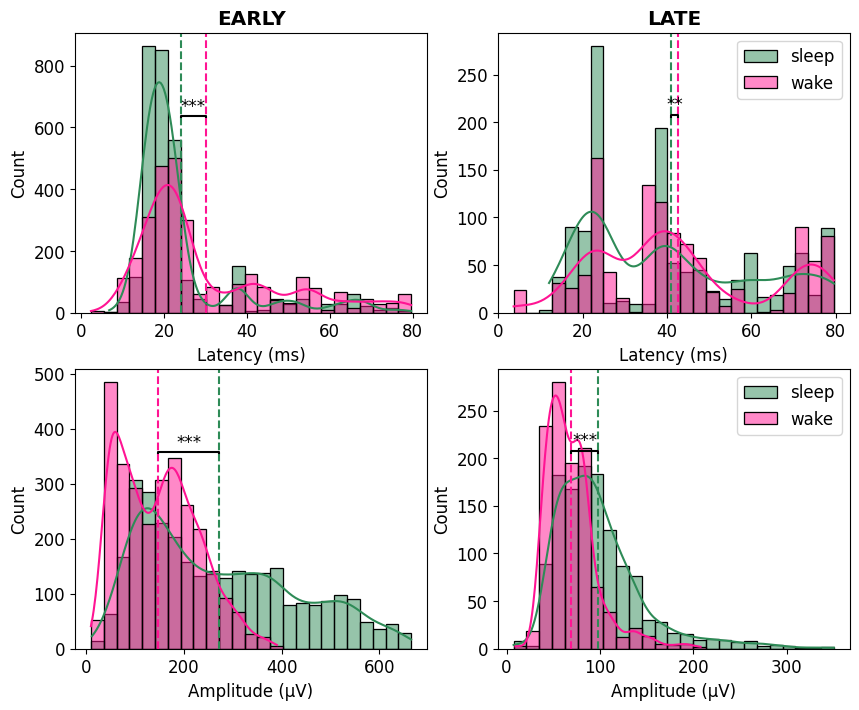

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "n.s."
    
def add_significance_bar(ax, x1, x2, y, text="***", h=2, text_offset=1):
    """
    Draws a significance bar with text between two points on the x-axis.
    ax: matplotlib Axes
    x1, x2: positions of the two groups
    y: height where the bar is placed
    text: significance marker (e.g., '*', '***')
    h: height of the bar above y
    text_offset: offset above the bar for text
    """
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c="k")
    ax.text((x1+x2)/2, y+h+text_offset, text, ha='center', va='bottom', fontsize=12)
    
def plot_latency_amplitude_hist(df, axes, lat_pvals, amp_pvals, bins_lat=20, bins_amp=20):
    """
    Make 2x2 histograms:
      Top row: latency (per region)
      Bottom row: amplitude (abs) (per region)
      Colors: State (sleep/wake)
    """

    regions = ["low", "high"]
    states = ['sleep', 'wake']

    for col, region in enumerate(regions):
        df_region = df[df["Region"] == region]

        # --- Latency (top row) ---
        ax_lat = axes[0, col]
        means_lat = []
        latencies_ms = df_region["Latency"] * 1000
        bin_edges_lat = np.linspace(latencies_ms.min(), latencies_ms.max(), bins_lat + 1)
        
        amplitudes = np.abs(df_region["Amplitude"])
        bin_edges_amp = np.linspace(amplitudes.min(), amplitudes.max(), bins_amp + 1)
        
        
        for state in states:
            subset = df_region[df_region["State"] == state]
            mean_val = np.mean(subset["Latency"] * 1000)
            ax_lat.axvline(mean_val, color=colors[state], linestyle="--")
            means_lat.append(mean_val)
            
            
            sns.histplot(subset["Latency"] * 1000,  # ms
                         bins=bin_edges_lat, kde=True,
                         color=colors[state], alpha=0.5,
                         label=state, ax=ax_lat, stat="count")
        ax_lat.set_title(f"{name_mapping[region].upper()}", weight="bold")
        ax_lat.set_xlabel("Latency (ms)")
        ax_lat.set_ylabel("Count")
        
        
        # add significance line between the two mean amplitudes
        # choose correct contrast
        if region == "low":
            p = lat_pvals["Sleep vs Wake (Low)"]
        else:
            p = lat_pvals["Sleep vs Wake (High)"]
        
        sig_text = p_to_stars(p)
        
        ymax = ax_lat.get_ylim()[1]
        add_significance_bar(ax_lat, means_lat[0], means_lat[1], ymax*0.7, text=sig_text)
        
        # --- Amplitude (bottom row) ---
        ax_amp = axes[1, col]
        means_amp = []

        for state in states:
            subset = df_region[df_region["State"] == state]
            mean_val = np.mean(np.abs(subset["Amplitude"]))
            ax_amp.axvline(mean_val, color=colors[state], linestyle="--")
            means_amp.append(mean_val)

            sns.histplot(np.abs(subset["Amplitude"]),
                         bins=bin_edges_amp, kde=True,
                         color=colors[state], alpha=0.5,
                         label=state, ax=ax_amp, stat="count")
        # ax_amp.set_title(f"Amplitude - {region.capitalize()} region")
        ax_amp.set_xlabel("Amplitude (µV)")
        ax_amp.set_ylabel("Count")
        
        # add significance line between the two mean amplitudes
        if region == "low":
            p = amp_pvals["Sleep vs Wake (Low)"]
        else:
            p = amp_pvals["Sleep vs Wake (High)"]
        
        sig_text = p_to_stars(p)
        
        ymax = ax_amp.get_ylim()[1]
        add_significance_bar(ax_amp, means_amp[0], means_amp[1], ymax*0.7, text=sig_text)
        
        
        if col == 1:  # only show legend once
            ax_lat.legend()
            ax_amp.legend()
        ax_amp.grid(False)
        ax_lat.grid(False)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

plot_latency_amplitude_hist(
    df_mega,
    axes,
    lat_pvals,
    amp_pvals,
    bins_lat=25,
    bins_amp=25
)

## Plot and Save Figure 2 (LFP Response and Statistical Summaries)

Plot that collects all the previous plots into Figure 2

Sound loaded successfully. Duration: 2.58 seconds


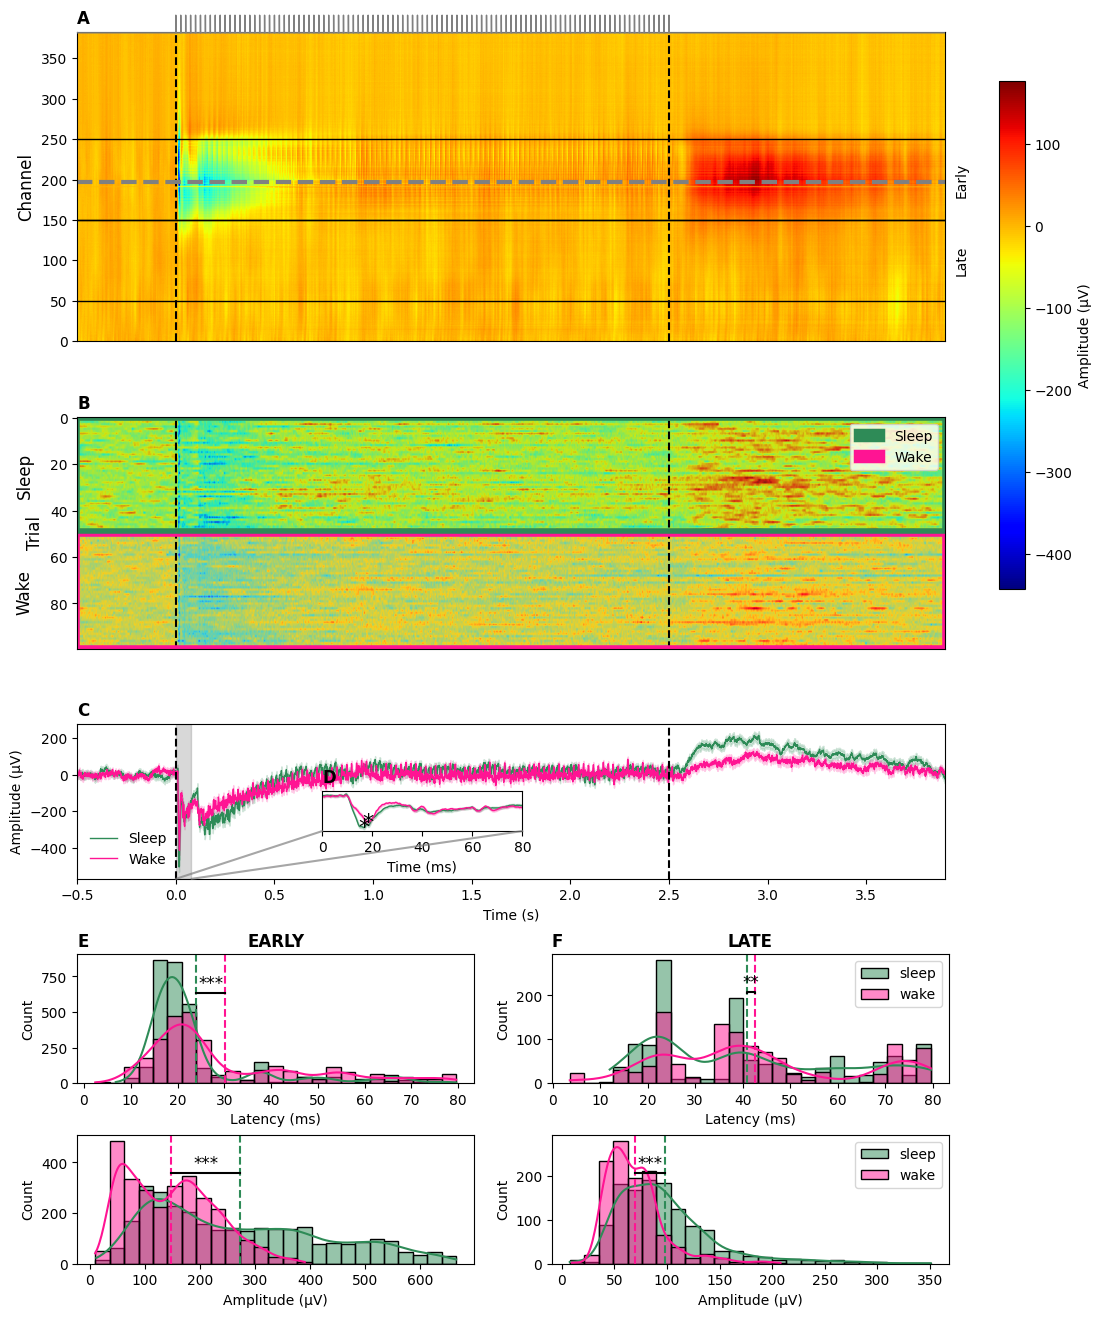

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import scipy.io
plt.style.use('default')  # resets to pre-Seaborn/Matplotlib default

### Function: Load Sound Waveform from .mat File
def load_sounwaveform(Sound_pick):
    Path_to_sounds = DATA_PATH + rf"\{Sound_pick}_sound.mat"

    # Load the sound data from the MAT file
    sound_data = scipy.io.loadmat(Path_to_sounds)
    sound_wave = sound_data['soundData']['soundwave'][0, 0].flatten()  # Extract the sound waveform
    sound_fs = 192000  # Sound sampling rate in Hz (192 kHz as mentioned)
    
    # Create a time vector for the sound (starting at 0)
    sound_duration = len(sound_wave) / sound_fs  # Duration in seconds
    sound_time = np.linspace(0, sound_duration, len(sound_wave))
    print(f"Sound loaded successfully. Duration: {sound_duration:.2f} seconds")
    
    buffer_sound_before = BUFFER_BEFORE_SEC * sound_fs
    buffer_sound_after = (BUFFER_AFTER_SEC - sound_duration) * sound_fs
    
    sound_wave_pad = np.pad(sound_wave, (int(buffer_sound_before), int(buffer_sound_after)), mode='constant')
    sound_time_pad = np.linspace(-BUFFER_BEFORE_SEC, BUFFER_AFTER_SEC, len(sound_wave_pad))
    return sound_wave_pad, sound_time_pad

### Function: Plot Sound Waveform
def plot_soundwaveform(ax, SoundType):
    """
    Plot sound waveform on the provided axis.
    """
    sound_wave_pad, sound_time_pad = load_sounwaveform(SoundType)

    ax.plot(sound_time_pad, sound_wave_pad, color='gray', linewidth=1)
    ax.set_xlim(sound_time_pad[0], sound_time_pad[-1])
    ax.axis('off')  # clean look

### Function: Plot LFP Mean Response Heatmap (Figure 2A)
def plot_panel_A(ax, LFPs_dict, SoundType, high_ch, low_ch):
    """
    Plot Panel A: mean LFP heatmap with channel markers, using existing axis.
    """
    mean_sleep = LFPs_dict[SoundType]['Mean_Sleep']
    mean_wake = LFPs_dict[SoundType]['Mean_Wake']
    peak_chan_sleep = LFPs_dict[SoundType]['Peak_ch']
    t_LFP = LFPs_dict[SoundType]['t_LFP']

    # Mean across sleep and wake
    mean_response = np.mean([mean_sleep, mean_wake], axis=0)

    # Heatmap
    im = ax.imshow(mean_response, aspect='auto', cmap='jet',
                   extent=[t_LFP[0], t_LFP[-1], 0, mean_sleep.shape[0]], origin='lower')
    ax.set_xlim([-BUFFER_BEFORE_SEC, BUFFER_AFTER_SEC])
    ax.axvline(0, color='k', linestyle='--')
    ax.axvline(2.5, color='k', linestyle='--')

    # Inset for sound waveform
    inset_ax = inset_axes(ax, width="100%", height="25%", bbox_to_anchor=(0,0.9,1,0.25),
                          bbox_transform=ax.transAxes, loc='center')
    plot_soundwaveform(inset_ax, SoundType)

    # Channel markers
    ax.axhline(peak_chan_sleep, color='gray', linestyle='--', lw=3)
    for c in [high_ch[0], high_ch[1], low_ch[0], low_ch[1]]:
        ax.axhline(c, color='black', linewidth=1)

    # Labels
    x_text = BUFFER_AFTER_SEC + (t_LFP[-1]-t_LFP[0])*0.01
    ax.text(x_text, (high_ch[0]+high_ch[1])/2, 'Late', va='center', ha='left', rotation='vertical')
    ax.text(x_text, (low_ch[0]+low_ch[1])/2, 'Early', va='center', ha='left', rotation='vertical')

    ax.set_ylabel("Channel", fontsize=12)
    ax.set_title('A', loc='left', weight='bold')
    # ax.set_xlabel("Time (s)")
    ax.set_xticks([])
    
    return im  # return image for optional colorbar

### Function: Plot Single-Trial LFP Heatmap (Figure 2B)
def plot_panel_B(ax, LFPs_dict, SoundType):
    """
    Plot Panel B: individual trial LFP heatmap for sleep and wake.
    Receives an axis from outside.
    """
    trials_sleep = LFPs_dict[SoundType]['Trials_sleep'].T  # trials x time bins
    trials_wake = LFPs_dict[SoundType]['Trials_Wake'].T
    t_LFP = LFPs_dict[SoundType]['t_LFP']

    # Combine trials vertically: sleep on top, wake below
    all_trials = np.vstack([trials_sleep, trials_wake])
    n_sleep = trials_sleep.shape[0]
    n_wake = trials_wake.shape[0]

    im = ax.imshow(all_trials, aspect='auto', cmap='jet',
                   extent=[t_LFP[0], t_LFP[-1], all_trials.shape[0]-0.5, -0.5])

    # Highlight sleep and wake regions with semi-transparent background
    ax.axhspan(-0.5, n_sleep-0.5, alpha=0.2, color=colors['sleep'])
    ax.axhspan(n_sleep-0.5, all_trials.shape[0]-0.5, alpha=0.2, color=colors['wake'])

    # Text labels for sleep/wake
    ax.text(-0.05, n_sleep/2, 'Sleep', transform=ax.get_yaxis_transform(),
            ha='right', va='center', fontsize=12, rotation=90)
    ax.text(-0.05, n_sleep + n_wake/2, 'Wake', transform=ax.get_yaxis_transform(),
            ha='right', va='center', fontsize=12, rotation=90)

    ax.set_ylabel("Trial", fontsize=12)
    ax.set_title('B', loc='left', weight='bold')
    # ax.set_xlabel("Time (s)")
    ax.set_xticks([])
    ax.set_xlim([-BUFFER_BEFORE_SEC, BUFFER_AFTER_SEC])
    ax.axvline(0, color='k', linestyle='--')
    ax.axvline(2.5, color='k', linestyle='--')
    
    import matplotlib.patches as patches
    n_sleep_trials = trials_sleep.shape[0]

    sleep_rect = patches.Rectangle(
        (ax.get_xlim()[0], n_sleep_trials),              # (x, y) position
        ax.get_xlim()[1] - ax.get_xlim()[0],     # width (full x-range)
        n_sleep_trials-1,                         # height
        linewidth=4, edgecolor=colors['wake'], facecolor='none', zorder=2
    )
    ax.add_patch(sleep_rect)
    
    wake_rect = patches.Rectangle(
        (ax.get_xlim()[0], 0),              # (x, y) position
        ax.get_xlim()[1] - ax.get_xlim()[0],     # width (full x-range)
        n_sleep_trials-1,                         # height
        linewidth=4, edgecolor=colors['sleep'], facecolor='none', zorder=2
    )
    ax.add_patch(wake_rect)
    
    square_sleep = patches.Patch(edgecolor=colors['sleep'], facecolor=colors['sleep'], linewidth=2.5, label='Sleep')
    square_wake = patches.Patch(edgecolor=colors['wake'], facecolor=colors['wake'], linewidth=2.5, label='Wake')
    
    # Add legend manually
    ax.legend(handles=[square_sleep, square_wake])
    return im

### Function: Plot Mean LFP Trace Over Time (Figure 2C)
def plot_panel_C(ax, LFPs_dict, SoundType):
    """
    Plot Panel C: mean LFP traces (Sleep vs Wake).
    Receives an axis from outside.
    """
    trials_sleep = LFPs_dict[SoundType]['Trials_sleep'].T  #  trials x time bins
    trials_wake = LFPs_dict[SoundType]['Trials_Wake'].T
    mean_sleep = trials_sleep.mean(axis=0)
    mean_wake = trials_wake.mean(axis=0)
    sem_sleep = trials_sleep.std(axis=0) / np.sqrt(trials_sleep.shape[0])    # sem over time
    sem_wake = trials_wake.std(axis=0) / np.sqrt(trials_sleep.shape[0])    # sem over time
    # mean_sleep = LFPs_dict[SoundType]['Mean_Sleep']
    # mean_wake = LFPs_dict[SoundType]['Mean_Wake']
    peak_chan_sleep = LFPs_dict[SoundType]['Peak_ch']

    t_LFP = LFPs_dict[SoundType]['t_LFP']

    # --- Plot Sleep ---
    ax.plot(t_LFP, mean_sleep, color=colors['sleep'], label="Sleep", lw=1)
    ax.fill_between(t_LFP, mean_sleep - sem_sleep, mean_sleep + sem_sleep, color=colors['sleep'], alpha=0.2)
    
    # --- Plot Wake ---
    ax.plot(t_LFP, mean_wake, color=colors['wake'], label="Wake", lw=1)
    ax.fill_between(t_LFP, mean_wake - sem_wake, mean_wake + sem_wake, color=colors['wake'], alpha=0.2)
    
    ax.set_xlim([-BUFFER_BEFORE_SEC, BUFFER_AFTER_SEC])
    ax.axvline(0, color='k', linestyle='--')
    ax.axvline(2.5, color='k', linestyle='--')
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title('C', loc='left', weight='bold')
    ax.legend(frameon=False)
    
    # --- Define zoom window (0–80 ms) ---
    mask_zoom = (t_LFP > 0) & (t_LFP < 0.08)
    x0, x1 = t_LFP[mask_zoom][0], t_LFP[mask_zoom][-1]

    # Shade that region
    ax.axvspan(x0, x1, color="gray", alpha=0.3)

    # --- Add inset (Panel D) ---
    x_anchor, y_anchor = 0.75, -200
    width, height = 2, 0.4
    axins = inset_axes(
        ax,
        width=width, height=height,
        bbox_to_anchor=(x_anchor, y_anchor, 1, 1),
        bbox_transform=ax.transData,
        loc="center"
    )
    
    plot_panel_D(axins, LFPs_dict, SoundType)
    
    from matplotlib.patches import ConnectionPatch
    # Connect left edge of shaded region to left edge of inset
    con1 = ConnectionPatch(
        xyA=(x0, ax.get_ylim()[0]), coordsA=ax.transData,
        xyB=(0, axins.get_ylim()[0]), coordsB=axins.transData,
        color='gray', linestyle='-', linewidth=1.5, alpha=0.7
    )
    ax.figure.add_artist(con1)
    
    # Connect right edge of shaded region to right edge of inset
    con2 = ConnectionPatch(
        xyA=(x1, ax.get_ylim()[0]), coordsA=ax.transData,
        xyB=(80, axins.get_ylim()[0]), coordsB=axins.transData,
        color='gray', linestyle='-', linewidth=1.5, alpha=0.7
    )
    ax.figure.add_artist(con2)

    return ax

### Function: Plot Zoomed-in LFP Trace (Figure 2D)
def plot_panel_D(ax, LFPs_dict, SoundType):
    """
    Plot Panel D: zoomed-in LFP traces (Sleep vs Wake) for the peak channel.
    Receives axis from outside.
    
    Parameters
    ----------
    ax : matplotlib axis
        Axis to plot into
    LFPs_dict : dict
        Dictionary with Mean_Sleep, Mean_Wake, t_LFP
    SoundType : int
        Sound identifier
    """
    trials_sleep = LFPs_dict[SoundType]['Trials_sleep'].T  #  trials x time bins
    trials_wake = LFPs_dict[SoundType]['Trials_Wake'].T
    mean_sleep = trials_sleep.mean(axis=0)
    mean_wake = trials_wake.mean(axis=0)
    sem_sleep = trials_sleep.std(axis=0) / np.sqrt(trials_sleep.shape[0])    # sem over time
    sem_wake = trials_wake.std(axis=0) / np.sqrt(trials_sleep.shape[0])    # sem over time
    
    peak_chan_sleep = LFPs_dict[SoundType]['Peak_ch']
    t_LFP = LFPs_dict[SoundType]['t_LFP']

    # --- Extract zoom window (0–50 ms) ---
    mask_zoom = (t_LFP > 0) & (t_LFP < 0.08)
    t_zoom = t_LFP[mask_zoom] * 1000  # ms
    sleep_zoom = mean_sleep[mask_zoom]
    wake_zoom = mean_wake[mask_zoom]
    sem_sleep_zoom = sem_sleep[mask_zoom]
    sem_wake_zoom = sem_wake[mask_zoom]
    
    # --- Plot traces ---
    ax.plot(t_zoom, sleep_zoom, color=colors['sleep'], lw=1, label="Sleep")
    ax.fill_between(t_zoom, sleep_zoom - sem_sleep_zoom, sleep_zoom + sem_sleep_zoom, color=colors['sleep'], alpha=0.2)

    ax.plot(t_zoom, wake_zoom, color=colors['wake'], lw=1, label="Wake")
    ax.fill_between(t_zoom, wake_zoom - sem_wake_zoom, wake_zoom + sem_wake_zoom, color=colors['wake'], alpha=0.2)

    # --- Mark latency points with stars ---
    ax.text(t_zoom[np.argmin(sleep_zoom)], sleep_zoom[np.argmin(sleep_zoom)],
            '*', color='k', ha='center', va='center', fontsize=16)
    ax.text(t_zoom[np.argmin(wake_zoom)], wake_zoom[np.argmin(wake_zoom)],
            '*', color='k', ha='center', va='center', fontsize=16)

    # --- Formatting ---
    ax.set_xlim([0, 80])
    ax.set_xlabel("Time (ms)")
    # ax.set_ylabel("Amplitude (µV)")
    ax.set_title('D', loc='left', weight='bold')
    # ax.set_xticks([])
    ax.set_yticks([])
    return ax


high_ch = subjects_data[subject_id]['high_ch']
low_ch = subjects_data[subject_id]['low_ch']

fig = plt.figure(figsize=(14, 16))
outer_gs = gridspec.GridSpec(4, 1, hspace=0.3, height_ratios=[2, 1.5, 1, 2])

axA = fig.add_subplot(outer_gs[0, :])
im = plot_panel_A(axA, LFPs_dict, SoundType, high_ch, low_ch)

axB = fig.add_subplot(outer_gs[1, :])
plot_panel_B(axB, LFPs_dict, SoundType)

axC = fig.add_subplot(outer_gs[2, :])
plot_panel_C(axC, LFPs_dict, SoundType)

# Colorbar
cbar = fig.colorbar(im, ax=[axA, axB, axC], shrink=0.6, pad=0.05)
cbar.set_label('Amplitude (µV)')
# Get current position
pos = cbar.ax.get_position()
cbar.ax.set_position([pos.x0, pos.y0 + 0.075, pos.width, pos.height])

# gs_last_row = gridspec.GridSpecFromSubplotSpec(2, 6, subplot_spec=outer_gs[3, :], wspace=0.5, hspace=0.4, width_ratios=[1,0.01,1,1,1,1])
gs_last_row = gridspec.GridSpecFromSubplotSpec(2, 5, subplot_spec=outer_gs[3, :], wspace=0.5, hspace=0.4, width_ratios=[1,1,1,1,0.85])

# axE = fig.add_subplot(gs_last_row[:, 0])
# plot_LFP_hist(axE, results, high_ch, low_ch, colors)

axF = [fig.add_subplot(gs_last_row[j, 0:2]) for j in range(2)]
axF[0].set_title('E', loc='left', weight='bold')

axG = [fig.add_subplot(gs_last_row[j, 2:4]) for j in range(2)]
axG[0].set_title('F', loc='left', weight='bold')
axes = np.stack([[axF[0], axG[0]],[axF[1], axG[1]]])
plot_latency_amplitude_hist(
    df_mega,
    axes,
    lat_pvals,
    amp_pvals,
    bins_lat=25,
    bins_amp=25
)

fig.savefig(DATA_PATH + r"\Figure_2.pdf", dpi=300)
fig.savefig(DATA_PATH + r"\Figure_2.tiff", dpi=300, bbox_inches='tight')
fig.savefig(DATA_PATH + r"\Figure_2.jpg", dpi=300, bbox_inches='tight')